In [1]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'
import Funciones as Funciones
from NNMF_GIF2 import NNMF_GIF
from pathlib import Path
from ipyfilechooser import FileChooser
import ipywidgets as widgets



w_i = []
h_i = []
flujo_ = []
error_i = []
f_ = []


In [2]:
FC = FileChooser('Señales AC3E/Femenino')
FC.layout = widgets.Layout(width='1000px')
display(FC)

FileChooser(path='G:\Mi unidad\Facultad\Beca CIN\NNMF-GIF\Señales AC3E\Femenino', filename='', title='', show_…

In [ ]:
B = 70
def INF(señal_ovv, fs=8000,fmin=200,fmax=1000,step=1,B=B):
    frec_formante     = -1
    error_minimo      = np.inf

    for f_i in range(fmin, fmax+1,step):
        Q    = f_i / B
        b, a = sig.iirnotch(w0=f_i/(fs/2), Q=Q)
        flujo_i = sig.filtfilt(b, a, señal_ovv)
        w,h = sig.freqz(b,a,fs=fs)
        error = np.sum(np.abs(np.gradient(np.gradient(flujo_i))))       
        if error < error_minimo:
            error_minimo = error
            frec_formante = f_i
        w_i.append(w)
        h_i.append(h)
        flujo_.append(flujo_i)
        error_i.append(error)
        f_.append(f_i) 
    Q = frec_formante / B
    b, a = sig.iirnotch(w0=frec_formante/(fs/2), Q=Q)
    flujo = sig.filtfilt(b, a, señal_ovv)

    return flujo,frec_formante,error_minimo,b,a

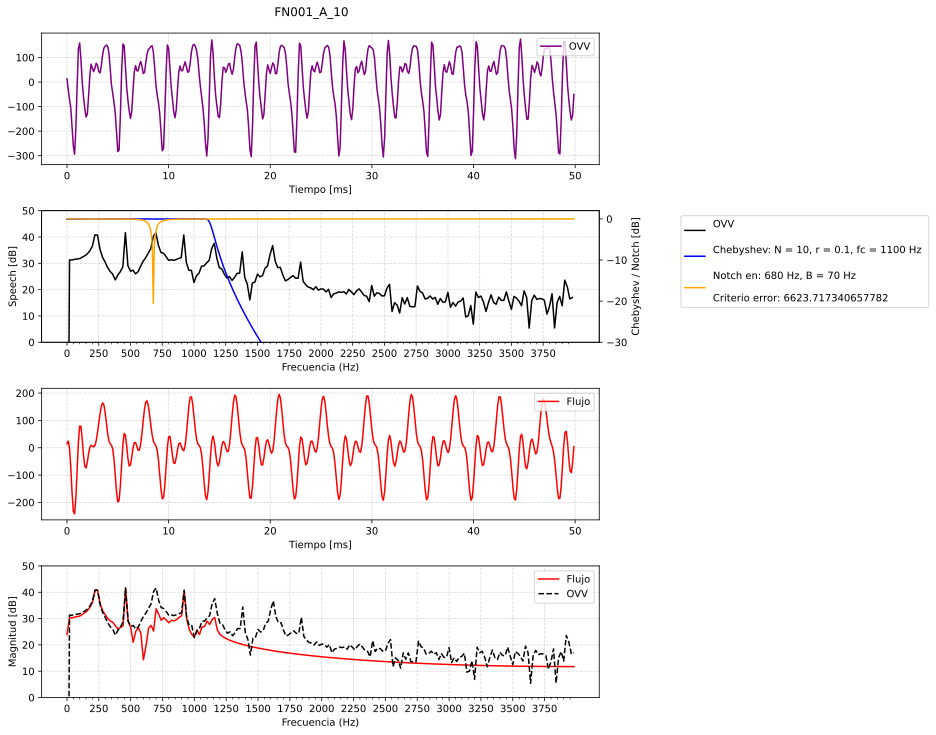

In [7]:
archivo = Path(FC.selected)
nombre_archivo = archivo.name
datos = np.loadtxt(archivo, delimiter='\t', skiprows=1)
fs_r = 8000 
señal_OVV_  = datos[:, 2] - np.mean(datos[:, 2])

orden = 10 
ripple = 0.1
fc     = 1100
b,a   = sig.cheby1(orden,ripple,fc,'lowpass',fs=fs_r)
señal_OVV_f = sig.filtfilt(b,a,señal_OVV_)

to = 0
tf = 50
tiempos       = np.arange(to,tf,1000/fs_r)
flujo_ovv, FF,error,b_notch,a_notch = INF(señal_OVV_f)

alfa_grid = 0.3
fig, ax = plt.subplots(4, 1, figsize=(10, 12))
fig.subplots_adjust(hspace=0.35)

ax[0].plot(tiempos, señal_OVV_, color='purple', label='OVV')
ax[0].legend(loc='upper right')
ax[0].grid(True, linestyle='dashed', color='gray', alpha=0.3, which='both')
ax[0].set_xlabel('Tiempo [ms]')

fftseñal_, fseñal_ = Funciones.FFT(señal_OVV_, fs_r)
line1, = ax[1].plot(fseñal_, 10*np.log10(abs(fftseñal_)), color='k', label='OVV \n')
w, h = sig.freqz(b,a,fs=fs_r)
ax1_ = ax[1].twinx()
line2, = ax1_.plot(w, 10*np.log10(abs(h)), color='b', label=f"Chebyshev: N = {orden}, r = {ripple}, fc = {fc} Hz \n")

w, h = sig.freqz(b_notch,a_notch,fs=fs_r)
line3, = ax1_.plot(w, 10*np.log10(abs(h)), color='orange', label=f'Notch en: {FF} Hz, B = {B} Hz \n \nCriterio error: {error}')
ax1_.set_ylim([-30,2])
ax[1].set_xlabel('Frecuencia (Hz)')
ax[1].set_ylabel('Speech [dB]')
ax1_.set_ylabel('Chebyshev / Notch [dB]')
ax[1].set_xticks(np.arange(0,fs_r/2,250))
ax[1].set_xticks(np.arange(0,fs_r/2,50),minor=True)
ax[1].grid(True,linestyle='dashed',color='gray',alpha=alfa_grid)
ax[1].set_ylim([0,50])
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax[1].legend(lines, labels, loc='upper right',bbox_to_anchor=(1.6,1))

ax[2].plot(tiempos, flujo_ovv, color='red', label='Flujo')
ax[2].legend(loc='upper right')
ax[2].grid(True, linestyle='dashed', color='gray', alpha=alfa_grid, which='both')
ax[2].set_xlabel('Tiempo [ms]');

fftseñal, fseñal = Funciones.FFT(flujo_ovv, fs_r)
ax[3].plot(fseñal, 10*np.log10(abs(fftseñal)), color='red', label='Flujo')
ax[3].plot(fseñal_, 10*np.log10(abs(fftseñal_)),linestyle='dashed',color='k',alpha=1, label='OVV')
ax[3].set_xlabel('Frecuencia (Hz)')
ax[3].set_ylabel('Magnitud [dB]')
ax[3].set_xticks(np.arange(0,fs_r/2,250))
ax[3].set_xticks(np.arange(0,fs_r/2,50),minor=True)
ax[3].grid(True,linestyle='dashed',color='gray',alpha=alfa_grid)
ax[3].set_ylim([0,50])
ax[3].legend(loc='upper right');

fig.suptitle(
    f"{nombre_archivo.removesuffix('.txt')}",
    fontsize=12,
    y=0.91
    );
fig.savefig("Resultados flujo/"+nombre_archivo.removesuffix('.txt')+'.pdf',bbox_inches = 'tight');


In [9]:
#
slider = widgets.IntSlider(
    value=200,
    min=200,
    max=1000,
    step=1,
    description='Frecuencia:',
    continuous_update=True
)
def graficar(indice):
    indice = indice -200

    fig, ax = plt.subplots(4, 1, figsize=(10, 12))
    fig.subplots_adjust(hspace=0.35)

    ax[0].plot(tiempos, señal_OVV_, color='purple', label='OVV')
    ax[0].legend(loc='upper right')
    ax[0].grid(True, linestyle='dashed', color='gray', alpha=0.3, which='both')
    ax[0].set_xlabel('Tiempo [ms]')

    fftseñal_, fseñal_ = Funciones.FFT(señal_OVV_, fs_r)
    line1, = ax[1].plot(fseñal_, 10*np.log10(abs(fftseñal_)), color='k', label='OVV \n')
    w, h = sig.freqz(b,a,fs=fs_r)
    ax1_ = ax[1].twinx()
    line2, = ax1_.plot(w, 10*np.log10(abs(h)), color='b', label=f"Chebyshev: N = {orden}, r = {ripple}, fc = {fc} Hz \n")

    w, h = sig.freqz(b_notch,a_notch,fs=fs_r)
    line3, = ax1_.plot(w_i[indice], 10*np.log10(abs(h_i[indice])), color='orange', label=f'Notch en: {f_[indice]} Hz, B = {B} Hz \n \nCriterio error: {error_i[indice]}')
    ax1_.set_ylim([-30,2])
    ax[1].set_xlabel('Frecuencia (Hz)')
    ax[1].set_ylabel('Speech [dB]')
    ax1_.set_ylabel('Chebyshev / Notch [dB]')
    ax[1].set_xticks(np.arange(0,fs_r/2,250))
    ax[1].set_xticks(np.arange(0,fs_r/2,50),minor=True)
    ax[1].grid(True,linestyle='dashed',color='gray',alpha=alfa_grid)
    ax[1].set_ylim([0,50])
    lines = [line1, line2, line3]
    labels = [l.get_label() for l in lines]
    ax[1].legend(lines, labels, loc='upper right',bbox_to_anchor=(1.6,1))

    ax[2].plot(tiempos, flujo_[indice], color='red', label='Flujo')
    ax[2].legend(loc='upper right')
    ax[2].grid(True, linestyle='dashed', color='gray', alpha=alfa_grid, which='both')
    ax[2].set_xlabel('Tiempo [ms]');

    fftseñal, fseñal = Funciones.FFT(flujo_[indice], fs_r)
    ax[3].plot(fseñal, 10*np.log10(abs(fftseñal)), color='red', label='Flujo')
    ax[3].plot(fseñal_, 10*np.log10(abs(fftseñal_)),linestyle='dashed',color='k',alpha=1, label='OVV')
    ax[3].set_xlabel('Frecuencia (Hz)')
    ax[3].set_ylabel('Magnitud [dB]')
    ax[3].set_xticks(np.arange(0,fs_r/2,250))
    ax[3].set_xticks(np.arange(0,fs_r/2,50),minor=True)
    ax[3].grid(True,linestyle='dashed',color='gray',alpha=alfa_grid)
    ax[3].set_ylim([0,50])
    ax[3].legend(loc='upper right');

    fig.suptitle(
        f"{nombre_archivo.removesuffix('.txt')}",
        fontsize=12,
        y=0.91
        );
    '''
    fig, ax = plt.subplots(4, 1, figsize=(10, 12))
    fig.subplots_adjust(hspace=0.35)
    ax1_ = ax[1].twinx()

    ax[0].plot(tiempos, señal_OVV_, color='green', label='OVV')
    ax[0].legend(loc='upper right')
    ax[0].grid(True, linestyle='dashed', color='gray', alpha=0.3, which='both')
    ax[0].set_xlabel('Tiempo [ms]')

    fftseñal, fseñal = Funciones.FFT(señal_OVV_, fs_r)
    ax[1].plot(fseñal, 10*np.log10(abs(fftseñal)), color='k', label='speech')
    ax[1].set_xlabel('Frecuencia (Hz)')
    ax[1].set_ylabel('Magnitud [dB]')
    ax[1].set_title(f'Frecuencia del Notch: {f_[indice]} Hz - Criterio error: {error_i[indice]}')
    ax[1].set_xticks(np.arange(0,fs_r/2,250))
    ax[1].set_xticks(np.arange(0,fs_r/2,50),minor=True)
    ax[1].grid(True,linestyle='dashed',color='gray',alpha=0.5)
    ax1_.plot(w_i[indice], 10*np.log10(abs(h_i[indice])), color='orange')

    ax[2].plot(tiempos, flujo_[indice], color='red', label='OVV filtrada')
    ax[2].legend(loc='upper right')
    ax[2].grid(True, linestyle='dashed', color='gray', alpha=0.3, which='both')
    ax[2].set_xlabel('Tiempo [ms]')
    '''
    plt.show()

out = widgets.interactive_output(graficar, {'indice': slider})
ui = widgets.VBox([slider, out])
display(ui)
